# Download and preprocess NorSWE dataset into Zarr format  

Data description paper: [Northern Hemisphere in situ snow water equivalent dataset (NorSWE, 1979–2021)](https://essd.copernicus.org/articles/17/3619/2025/)

Zenodo dataset: 
[Northern Hemisphere historical in-situ Snow Water Equivalent dataset (NorSWE, 1979-2021)](https://zenodo.org/records/15263370)


In [1]:
import requests
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import zarr 
import netCDF4
import shutil
import easysnowdata
import matplotlib.pyplot as plt
import contextily as ctx
import gc
import os

data_dir = Path("data/NorSWE")
data_dir.mkdir(parents=True, exist_ok=True)

zenodo_record = "15263370"
zip_filename = "NorSWE-NorEEN_1979-2021_v3.zip"
zip_filepath = data_dir / zip_filename

zarr_filepath = data_dir / "NorSWE.zarr"

base_url = f"https://zenodo.org/records/{zenodo_record}/files"

In [3]:
# Download ZIP (2.4 GB — skipped if already present)
if not zip_filepath.exists():
    print(f"Downloading {zip_filename}...")
    with requests.get(f"{base_url}/{zip_filename}", stream=True) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        downloaded = 0
        with open(zip_filepath, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8 * 1024 * 1024):
                f.write(chunk)
                downloaded += len(chunk)
                if total:
                    print(f"  {downloaded / 1e9:.2f} / {total / 1e9:.2f} GB", end='\r')
    print(f"\nDownloaded {zip_filename}")
else:
    print(f"{zip_filename} already exists")

# Extract NetCDF
if not any(data_dir.rglob("*.nc")):
    print("Extracting...")
    with zipfile.ZipFile(zip_filepath, 'r') as zf:
        zf.extractall(data_dir)
    print("Extraction complete")
else:
    print("Already extracted")

NorSWE-NorEEN_1979-2021_v3.zip already exists
Extracting...
Extraction complete


In [4]:
# Find the NetCDF file
netcdf_filepath = list(data_dir.rglob("*.nc"))[0]
netcdf_filepath

PosixPath('data/NorSWE/NorSWE-NorEEN_1979-2021_v3.nc')

In [5]:
# how big is the zip and the extracted file?
zip_size_gb = zip_filepath.stat().st_size / 1e9
nc_size_gb = netcdf_filepath.stat().st_size / 1e9
print(f"ZIP size: {zip_size_gb:.2f} GB")
print(f"Extracted NetCDF size: {nc_size_gb:.2f} GB")

ZIP size: 2.38 GB
Extracted NetCDF size: 21.65 GB


In [6]:
# Open the dataset — inspect structure before committing to a full load
FLAG_VARS = ['data_flag_snw', 'data_flag_snd', 'qc_flag_snw', 'qc_flag_snd']

NorSWE_ds = xr.open_dataset(netcdf_filepath, chunks="auto", drop_variables=FLAG_VARS)

NorSWE_ds = NorSWE_ds.set_coords(['elevation','lat', 'lon', 'mmask', 'source','station_name','type_mes'])

#rename lat and lon to latitude and longitude
NorSWE_ds = NorSWE_ds.rename({'lat': 'latitude', 'lon': 'longitude'})

NorSWE_ds.attrs['source_url'] = 'https://zenodo.org/records/15263370'
NorSWE_ds.attrs['reference'] = 'Pirazzini et al., 2025, ESSD, https://essd.copernicus.org/articles/17/3619/2025/'
NorSWE_ds

<xarray.Dataset> Size: 2GB
Dimensions:       (station_id: 10153, time: 15706)
Coordinates:
  * station_id    (station_id) <U32 1MB 'CanSWE-ALE-05AA805' ... 'NVE-2.277'
    latitude      (station_id) float32 41kB dask.array<chunksize=(10153,), meta=np.ndarray>
    longitude     (station_id) float32 41kB dask.array<chunksize=(10153,), meta=np.ndarray>
    elevation     (station_id) float32 41kB dask.array<chunksize=(10153,), meta=np.ndarray>
    source        (station_id) <U63 3MB dask.array<chunksize=(10153,), meta=np.ndarray>
    station_name  (station_id) <U63 3MB dask.array<chunksize=(10153,), meta=np.ndarray>
    type_mes      (station_id) uint8 10kB dask.array<chunksize=(10153,), meta=np.ndarray>
    mmask         (station_id) uint8 10kB dask.array<chunksize=(10153,), meta=np.ndarray>
  * time          (time) datetime64[ns] 126kB 1979-01-01 ... 2021-12-31
Data variables:
    snw           (time, station_id) float32 638MB dask.array<chunksize=(6732, 4353), meta=np.ndarray>
    snd           (time, station_id) float32 638MB dask.array<chunksize=(6732, 4353), meta=np.ndarray>
    den           (time, station_id) float32 638MB dask.array<chunksize=(6732, 4353), meta=np.ndarray>
Attributes:
    Conventions:    CF-1.9
    Title:          Northern Hemisphere in situ SWE 1979-2021 v3
    Latest_update:  April 2025
    Source:         Environment and Climate Change Canada and partners (https...
    Distribution:   CanSWE data are redistributed under the Open Government L...
    Comment:        See Vionnet et al. (ESSD, 2021) for a description of the ...
    source_url:     https://zenodo.org/records/15263370
    reference:      Pirazzini et al., 2025, ESSD, https://essd.copernicus.org...

In [7]:
# how much memory does the dataset take up in RAM when loaded?
print(f"Estimated RAM usage when loaded: {NorSWE_ds.nbytes / 1e9:.2f} GB")

Estimated RAM usage when loaded: 1.92 GB


In [13]:
if zarr_filepath.exists():
    shutil.rmtree(zarr_filepath)
    print(f'{zarr_filepath} already exists, deleted for fresh conversion')
    
NorSWE_ds.to_zarr(zarr_filepath, mode='w')

# print the size of the zarr directory on disk
zarr_size_gb = sum(f.stat().st_size for f in zarr_filepath.rglob("*") if f.is_file()) / 1e9
print(f"Zarr size on disk before adding flags: {zarr_size_gb:.2f} GB")

data/NorSWE/NorSWE.zarr already exists, deleted for fresh conversion


/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=63, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=32, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with th

Zarr size on disk before adding flags: 0.04 GB


In [14]:
CHUNK_SIZE = 1000

QC_FLAG_DEFINITIONS = {
    'H': 'SD > 3 m (>8 m where mmask=1); SD set to NaN',
    'M': 'Data masked in previous update of CHSSD',
    'W': 'SWE > 3000 kg/m² (>8000 where mmask=1); SWE set to NaN',
    'D': 'Derived bulk snow density failed 25-700 kg/m³; SD, SWE, density set to NaN',
}

DATA_FLAG_DEFINITIONS = {
    'A': 'Sampling problems',
    'B': 'Manual snow survey conducted outside the nominal sampling period',
    'C': 'Combination of A and B',
    'E': 'Estimate',
    'G': 'Measurement location >1 km from station coordinate (Saskatchewan-specific)',
    'M': 'Missing',
    'R': 'Revised data',
    'T': 'Trace (includes patchy snow conditions)',
    'Y': 'Precise sampling date not available',
    'AI': 'Airborne gamma: soil moisture interpolated from airborne measurements',
    'AM': 'Airborne gamma: airborne soil moisture measurement',
    'GI': 'Airborne gamma: soil moisture interpolated from ground measurements',
    'SE': 'Airborne gamma: subjective soil moisture estimate',
    'MM-avgX': 'Airborne gamma: average of X observations with soil moisture method MM',
}



store = zarr.open_group(zarr_filepath, mode='a')

FLAG_CONFIGS = [
    ('qc_flag_snw',   ['', 'D', 'M', 'W'],  QC_FLAG_DEFINITIONS),
    ('qc_flag_snd',   ['', 'D', 'H', 'M'],  QC_FLAG_DEFINITIONS),
    ('data_flag_snw', None,                   DATA_FLAG_DEFINITIONS),
    ('data_flag_snd', None,                   DATA_FLAG_DEFINITIONS),
]

with netCDF4.Dataset(netcdf_filepath) as f:
    for var_name, known_vocab, definitions in FLAG_CONFIGS:
        var = f.variables[var_name]
        n_time, n_station = var.shape

        # Discover vocab if not known (data_flag_* has dynamic MM-avgX values)
        if known_vocab is None:
            unique_vals = set()
            for t0 in range(0, n_time, CHUNK_SIZE):
                chunk = var[t0:min(t0 + CHUNK_SIZE, n_time), :]
                unique_vals.update(chunk.ravel().tolist())
                del chunk; gc.collect()
            vocab = [''] + sorted(v for v in unique_vals if v != '')
        else:
            vocab = known_vocab

        z = store.create_array(
            var_name, shape=(n_time, n_station), dtype='int8',
            chunks=(CHUNK_SIZE, n_station), overwrite=True,
            dimension_names=['time', 'station_id'],
        )
        # _ARRAY_DIMENSIONS is what xr.open_zarr uses to assign dims
        z.attrs['vocab'] = vocab
        z.attrs['flag_definitions'] = definitions
        z.attrs['description'] = f'{var_name} int8-encoded; vocab[i]=string, 0=no flag'

        for t0 in range(0, n_time, CHUNK_SIZE):
            t1 = min(t0 + CHUNK_SIZE, n_time)
            chunk = var[t0:t1, :]                    # ~50 MB strings, freed each iter
            encoded = np.zeros((t1 - t0, n_station), dtype=np.int8)
            for code, val in enumerate(vocab[1:], 1):
                encoded[chunk == val] = code
            z[t0:t1] = encoded
            del chunk, encoded; gc.collect()
            print(f"  {var_name}: {t1}/{n_time}", end='\r')
        print(f"  {var_name}: done  vocab={vocab}")

zarr.consolidate_metadata(zarr_filepath)

  qc_flag_snw: done  vocab=['', 'D', 'M', 'W']
  qc_flag_snd: done  vocab=['', 'D', 'H', 'M']
  data_flag_snw: done  vocab=['', 'A', 'AI', 'AI-avg2', 'AI-avg3', 'AM', 'AM-avg2', 'AM-avg3', 'B', 'C', 'E', 'G', 'GI', 'M', 'R', 'SE', 'SE-avg2', 'SE-avg3', 'T', 'Y']
  data_flag_snd: done  vocab=['', 'A', 'B', 'C', 'E', 'G', 'M', 'R', 'T', 'Y']


<Group file://data/NorSWE/NorSWE.zarr>

In [15]:
# print the size of the zarr directory on disk
zarr_size_gb = sum(f.stat().st_size for f in zarr_filepath.rglob("*") if f.is_file()) / 1e9
print(f"Zarr size on disk after adding flags: {zarr_size_gb:.2f} GB")

Zarr size on disk after adding flags: 0.04 GB


## Confirm Zarr version of the dataset is complete and remove downloaded zip and netcdf files that are wayyyy too large

In [16]:
NorSWE_ds = xr.open_dataset(zarr_filepath)
NorSWE_ds

<xarray.Dataset> Size: 3GB
Dimensions:        (time: 15706, station_id: 10153)
Coordinates:
  * time           (time) datetime64[ns] 126kB 1979-01-01 ... 2021-12-31
  * station_id     (station_id) <U32 1MB 'CanSWE-ALE-05AA805' ... 'NVE-2.277'
    elevation      (station_id) float32 41kB ...
    latitude       (station_id) float32 41kB ...
    longitude      (station_id) float32 41kB ...
    mmask          (station_id) uint8 10kB ...
    source         (station_id) <U63 3MB ...
    station_name   (station_id) <U63 3MB ...
    type_mes       (station_id) uint8 10kB ...
Data variables:
    data_flag_snd  (time, station_id) int8 159MB ...
    data_flag_snw  (time, station_id) int8 159MB ...
    den            (time, station_id) float32 638MB ...
    qc_flag_snd    (time, station_id) int8 159MB ...
    qc_flag_snw    (time, station_id) int8 159MB ...
    snd            (time, station_id) float32 638MB ...
    snw            (time, station_id) float32 638MB ...
Attributes:
    Conventions:    CF-1.9
    Title:          Northern Hemisphere in situ SWE 1979-2021 v3
    Latest_update:  April 2025
    Source:         Environment and Climate Change Canada and partners (https...
    Distribution:   CanSWE data are redistributed under the Open Government L...
    Comment:        See Vionnet et al. (ESSD, 2021) for a description of the ...
    source_url:     https://zenodo.org/records/15263370
    reference:      Pirazzini et al., 2025, ESSD, https://essd.copernicus.org...

In [17]:
if os.path.exists(netcdf_filepath):
    os.remove(netcdf_filepath)
    print(f'{netcdf_filepath} deleted to save space')
if os.path.exists(zip_filepath):
    os.remove(zip_filepath)
    print(f'{zip_filepath} deleted to save space')

data/NorSWE/NorSWE-NorEEN_1979-2021_v3.nc deleted to save space
data/NorSWE/NorSWE-NorEEN_1979-2021_v3.zip deleted to save space


## Inspect distribution of sites

In [18]:
NorSWE_gdf = gpd.GeoDataFrame(
    {
        'station_id':   NorSWE_ds['station_id'].values,
        'station_name': NorSWE_ds['station_name'].values,
        'source':       NorSWE_ds['source'].values,
        'elevation':    NorSWE_ds['elevation'].values,
        'type_mes':     NorSWE_ds['type_mes'].values,
        'mmask':        NorSWE_ds['mmask'].values,
    },
    geometry=gpd.points_from_xy(NorSWE_ds['longitude'].values, NorSWE_ds['latitude'].values),
    crs='EPSG:4326',
)

NorSWE_gdf

,station_id,station_name,source,elevation,type_mes,mmask,geometry
0,CanSWE-ALE-05AA805,WEST CASTLE SNOW,CanSWEv6-Alberta Environment,1525.000000,0,1,POINT (-114.35 49.26667)
1,CanSWE-ALE-05AA806,RACE HORSE CREEK,CanSWEv6-Alberta Environment,1920.000000,0,1,POINT (-114.63333 49.81667)
2,CanSWE-ALE-05AD802,MIDDLE DRYWOOD,CanSWEv6-Alberta Environment,1570.000000,0,1,POINT (-114.05 49.25)
3,CanSWE-ALE-05AE810,\LEE CREEK \\P\\\,CanSWEv6-Alberta Environment,1525.000000,0,0,POINT (-113.56667 49.03333)
4,CanSWE-ALE-05AE811,\LEE CREEK \\D\\\,CanSWEv6-Alberta Environment,1660.000000,0,1,POINT (-113.61667 49.01667)
...,...,...,...,...,...,...,...
10148,NVE-2.286,ATNA-900,NVE,900.000000,0,1,POINT (10.04563 61.96072)
10149,NVE-2.293,ATNA-1000,NVE,1000.000000,0,1,POINT (10.05904 61.95533)
10150,NVE-2.308,ATNA-1100,NVE,1100.000000,0,1,POINT (10.07666 61.94841)
10151,NVE-2.309,ATNA-1200,NVE,1200.000000,0,1,POINT (10.09257 61.95081)


In [19]:
NorSWE_gdf.explore(
    column='elevation',
    cmap='terrain',
    tooltip=['station_id', 'station_name', 'source', 'elevation'],
    marker_kwds={'radius': 4},
)

## Compare NorSWE vs SNOTEL data for same site...

In [20]:
StationsWUS = easysnowdata.automatic_weather_stations.StationCollection()
StationsWUS.get_entire_data_archive()
stations_swe_WUS_da = StationsWUS.entire_data_archive['WTEQ']
paradise_SNOTEL_swe_da = stations_swe_WUS_da.sel(station="679_WA_SNTL")
paradise_SNOTEL_swe_mm_da = 1000.0*paradise_SNOTEL_swe_da

Geodataframe with all stations has been added to the Station object. Please use the .all_stations attribute to access.
Use the .get_data(stations=geodataframe/string/list,variables=string/list,start_date=str,end_date=str) method to fetch data for specific stations and variables.
Decompressing data...
Creating xarray.Dataset from the uncompressed data...


/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/easysnowdata/automatic_weather_stations.py:422: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  all_stations_ds = xr.concat(datasets, dim="station", coords="all")


Done! Entire archive dataset has been added to the station object. Please use the .entire_data_archive attribute to access.


In [21]:
paradise_NorSWE_ds = NorSWE_ds.sel(station_id="SNOTEL-679")
paradise_NorSWE_ds

<xarray.Dataset> Size: 378kB
Dimensions:        (time: 15706)
Coordinates:
  * time           (time) datetime64[ns] 126kB 1979-01-01 ... 2021-12-31
    elevation      float32 4B 1.564e+03
    latitude       float32 4B 46.78
    longitude      float32 4B -121.7
    mmask          uint8 1B 1
    source         <U63 252B 'Snotel US network'
    station_id     <U32 128B 'SNOTEL-679'
    station_name   <U63 252B 'PARADISE'
    type_mes       uint8 1B 2
Data variables:
    data_flag_snd  (time) int8 16kB ...
    data_flag_snw  (time) int8 16kB ...
    den            (time) float32 63kB ...
    qc_flag_snd    (time) int8 16kB ...
    qc_flag_snw    (time) int8 16kB ...
    snd            (time) float32 63kB ...
    snw            (time) float32 63kB ...
Attributes:
    Conventions:    CF-1.9
    Title:          Northern Hemisphere in situ SWE 1979-2021 v3
    Latest_update:  April 2025
    Source:         Environment and Climate Change Canada and partners (https...
    Distribution:   CanSWE data are redistributed under the Open Government L...
    Comment:        See Vionnet et al. (ESSD, 2021) for a description of the ...
    source_url:     https://zenodo.org/records/15263370
    reference:      Pirazzini et al., 2025, ESSD, https://essd.copernicus.org...

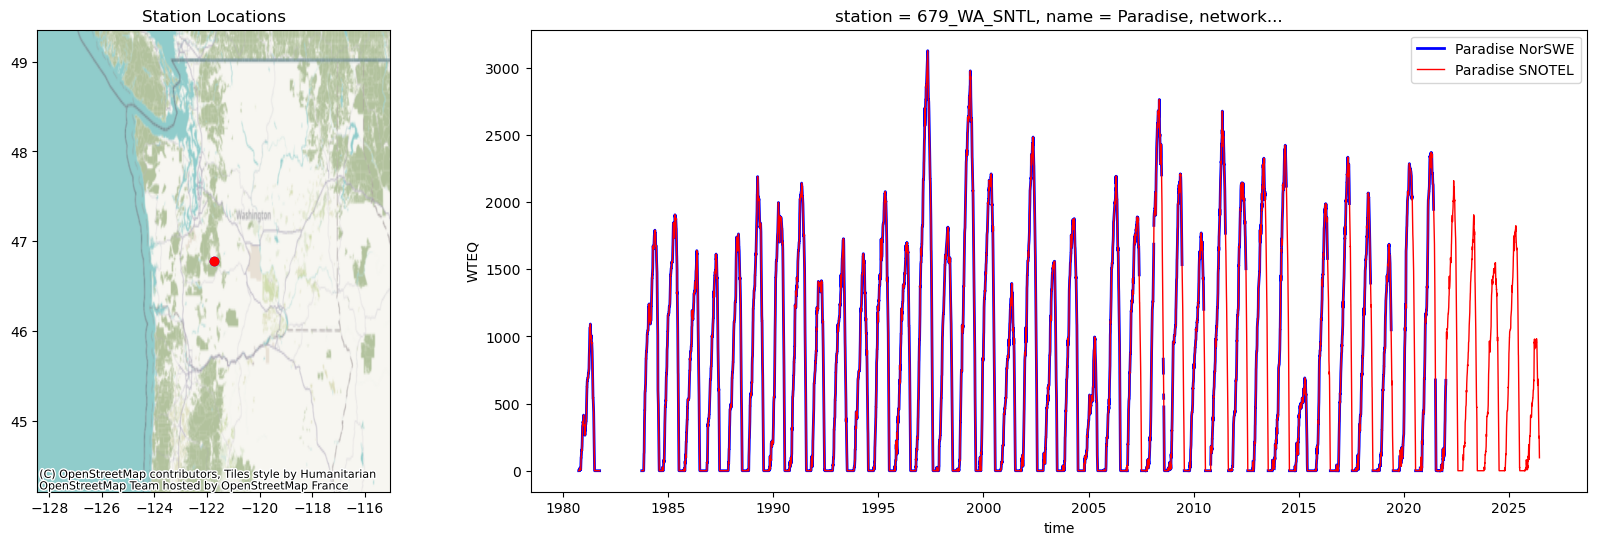

In [22]:
f,ax=plt.subplots(ncols=2, nrows=1, figsize=(20,6), gridspec_kw={'width_ratios': [1, 3]})

# geographic positions of stations 56164 and 54792, and the Paradise SNOTEL station

ax[0].scatter(paradise_NorSWE_ds.longitude, paradise_NorSWE_ds.latitude, label='NorSWE SNOTEL 679', color='blue')
ax[0].scatter(paradise_SNOTEL_swe_mm_da.longitude, paradise_SNOTEL_swe_mm_da.latitude, label='Paradise SNOTEL', color='red')
#ax[0].legend()
ax[0].set_title('Station Locations')
ctx.add_basemap(ax[0], crs='EPSG:4326')
# ax[0].set_xlim(-121.8, -121.7)
# ax[0].set_ylim(46.75, 46.8)


# time series
paradise_NorSWE_ds['snw'].plot(ax=ax[1], label='Paradise NorSWE', color='blue',zorder=1, linewidth=2)
paradise_SNOTEL_swe_mm_da.plot(ax=ax[1], label='Paradise SNOTEL', color='red',zorder=2, linewidth=1)

ax[1].legend()

(np.float64(14610.0), np.float64(20088.0))

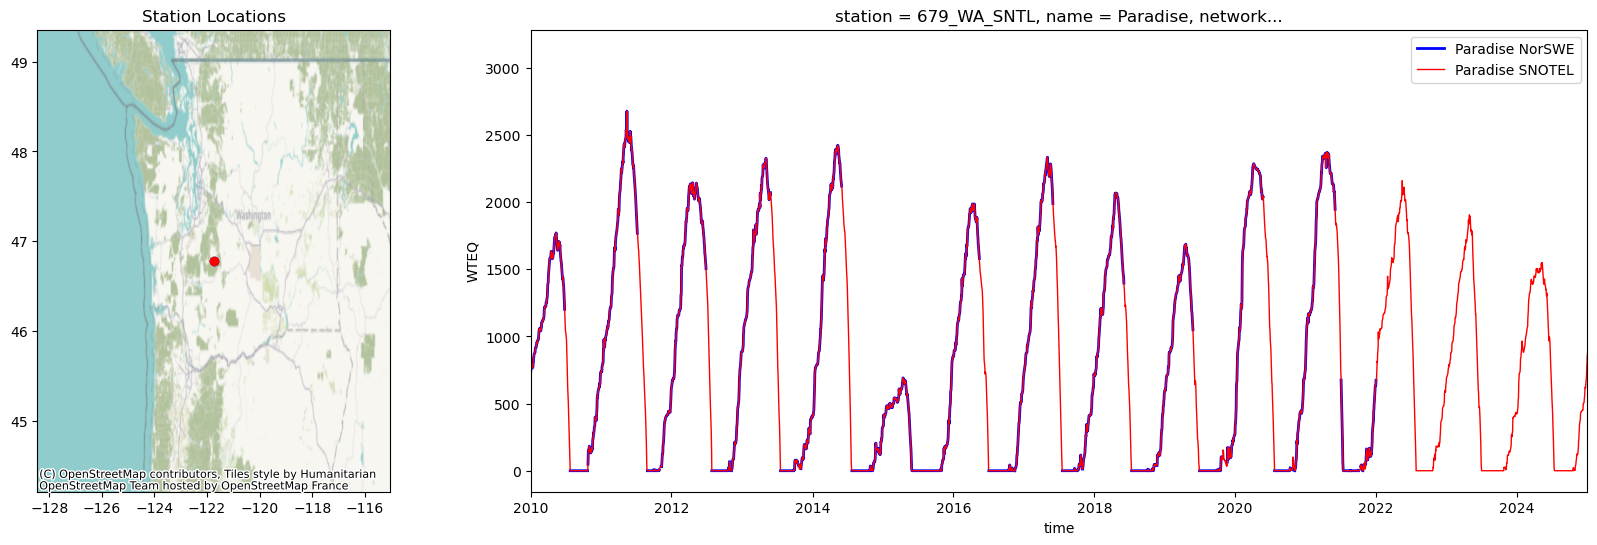

In [23]:
f,ax=plt.subplots(ncols=2, nrows=1, figsize=(20,6), gridspec_kw={'width_ratios': [1, 3]})

# geographic positions of stations 56164 and 54792, and the Paradise SNOTEL station

ax[0].scatter(paradise_NorSWE_ds.longitude, paradise_NorSWE_ds.latitude, label='NorSWE SNOTEL 679', color='blue')
ax[0].scatter(paradise_SNOTEL_swe_mm_da.longitude, paradise_SNOTEL_swe_mm_da.latitude, label='Paradise SNOTEL', color='red')
#ax[0].legend()
ax[0].set_title('Station Locations')
ctx.add_basemap(ax[0], crs='EPSG:4326')
# ax[0].set_xlim(-121.8, -121.7)
# ax[0].set_ylim(46.75, 46.8)


# time series
paradise_NorSWE_ds['snw'].plot(ax=ax[1], label='Paradise NorSWE', color='blue',zorder=1, linewidth=2)
paradise_SNOTEL_swe_mm_da.plot(ax=ax[1], label='Paradise SNOTEL', color='red',zorder=2, linewidth=1)

ax[1].legend()

ax[1].set_xlim([pd.to_datetime('2010-01-01'), pd.to_datetime('2024-12-31')])

(np.float64(18262.0), np.float64(19357.0))

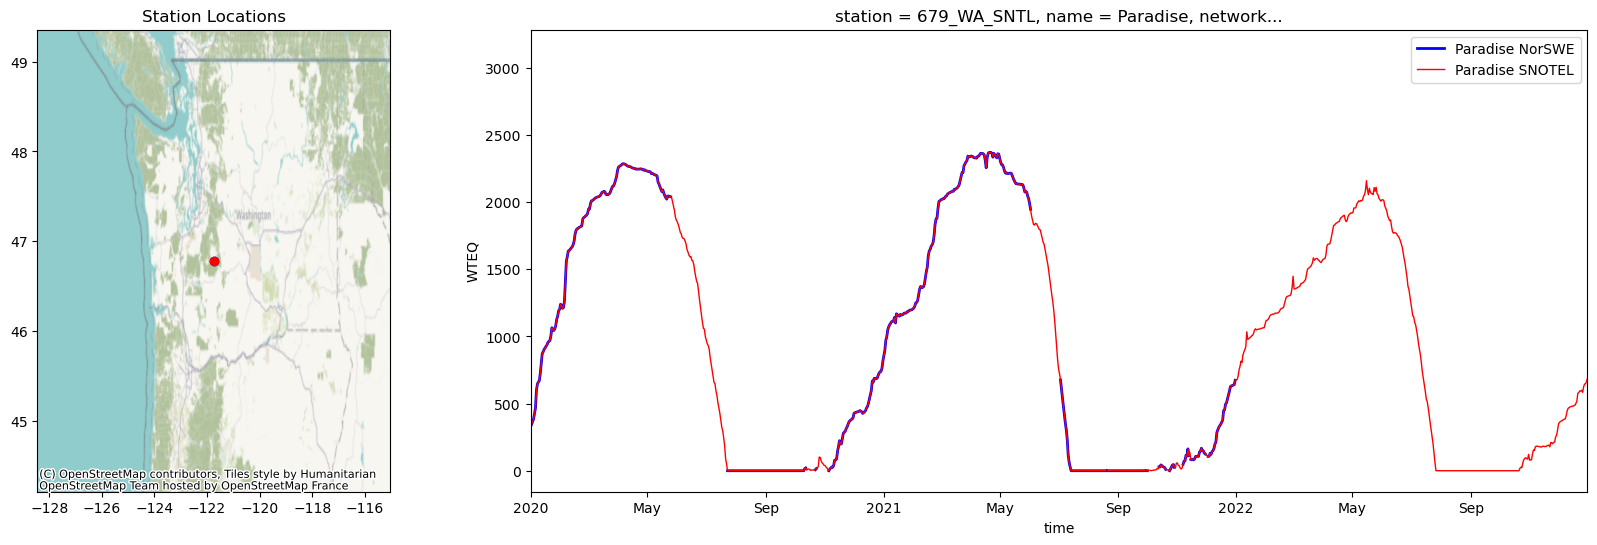

In [24]:
f,ax=plt.subplots(ncols=2, nrows=1, figsize=(20,6), gridspec_kw={'width_ratios': [1, 3]})

# geographic positions of stations 56164 and 54792, and the Paradise SNOTEL station

ax[0].scatter(paradise_NorSWE_ds.longitude, paradise_NorSWE_ds.latitude, label='NorSWE SNOTEL 679', color='blue')
ax[0].scatter(paradise_SNOTEL_swe_mm_da.longitude, paradise_SNOTEL_swe_mm_da.latitude, label='Paradise SNOTEL', color='red')
#ax[0].legend()
ax[0].set_title('Station Locations')
ctx.add_basemap(ax[0], crs='EPSG:4326')
# ax[0].set_xlim(-121.8, -121.7)
# ax[0].set_ylim(46.75, 46.8)


# time series
paradise_NorSWE_ds['snw'].plot(ax=ax[1], label='Paradise NorSWE', color='blue',zorder=1, linewidth=2)
paradise_SNOTEL_swe_mm_da.plot(ax=ax[1], label='Paradise SNOTEL', color='red',zorder=2, linewidth=1)

ax[1].legend()

ax[1].set_xlim([pd.to_datetime('2020-01-01'), pd.to_datetime('2022-12-31')])